# Sensitivity Analysis: Salary Cap

**Author:** Matteo
# Introduction
## Why this notebook

Notebook 04 generates the resource dataset using DiCE, with the team’s original salary cap (+50%). That computation takes about 10 minutes because DiCE runs on all at-risk employees individually.

If we were to put the sensitivity analysis directly in 4, every time we rerun the notebook, to adjust a chart, add a metric, or fix a bug, it would take 40+ minutes instead of 10, because DiCE would run 4 times instead of once.3.b This separation is an explicit choice for computational reproducibility: 3.a produces the base data (run once), 3.b explores parameter variations (run separately). It’s the same logic as separating preprocessing from analysis in ML; you don’t rerun preprocessing every time you change a plot.

## What we analyze

Notebook 04 showed nearly 100% effectiveness for all subgroups. This raises a legitimate question: are the FACTS results robust, or are they an artifact of an overly generous salary cap?

A +50% increase isn’t realistic in most HR contexts. By lowering the cap, DiCE has less leeway, and employees who can no longer find recourse might not be evenly distributed among Gender, Age Group, and Marital Status.

We rerun build_recourse_dataset with three levels of salary cap:


| Config | Cap | Rationale |
|----------|------|---------------------------|
| tight | +20% | Realistic retention offer |
| moderate | +35% | Generous but plausible |
| loose | +50% | Team's original baseline |

This directly operationalizes the idea of Equal Effectiveness within Budget from FACTS (Kavouras et al., NeurIPS 2023): here, the budget isn't the L1 cost of recourse, but the company's salary budget. The sensitivity of each subgroup to this parameter reveals structural biases that aggregate effectiveness hides.


# 0. Setup

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import dice_ml

from utils import (
    ScaledModelWrapper, load_artifacts, load_raw_with_split,
    build_recourse_dataset, get_project_paths,
    PROTECTED_ATTRIBUTES, SEED_DICE,
    IMMUTABLE, PERMITTED_RANGE, THRESHOLD_RF, THRESHOLD_XGB
)

PATHS     = get_project_paths()
N_CF      = 3

print('Paths:')
for k, v in PATHS.items():
    print(f'  {k}: {v}')


Paths:
  BASE: c:\Users\kamil\Desktop_new\Local\Universidad\H512 Current Trends\infoh512-project
  DATA: c:\Users\kamil\Desktop_new\Local\Universidad\H512 Current Trends\infoh512-project\data\processed
  RF: c:\Users\kamil\Desktop_new\Local\Universidad\H512 Current Trends\infoh512-project\data\models\RF
  XGBoost: c:\Users\kamil\Desktop_new\Local\Universidad\H512 Current Trends\infoh512-project\data\models\XGBoost
  FAIRNESS: c:\Users\kamil\Desktop_new\Local\Universidad\H512 Current Trends\infoh512-project\data\fairness


## 0.1. Load data and models

Identical to notebook 04; we need the same starting point.

In [2]:
df_raw, df_encoded, feature_cols = load_raw_with_split()
rf  = load_artifacts(PATHS['RF'])
xgb = load_artifacts(PATHS['XGBoost'])
feature_names = rf['feature_names']

rf_wrapper  = ScaledModelWrapper(rf['model'],  rf['scaler'],  feature_names)
xgb_wrapper = ScaledModelWrapper(xgb['model'], xgb['scaler'], feature_names)
print(f'Dataset: {len(df_raw)} employees | Features: {len(feature_names)}')
print('Models loaded.')


Dataset: 1470 employees | Features: 30
Models loaded.


# 1. Build DiCE explainers

Same configuration as notebook 04 — only the salary cap will change.

In [3]:
dice_df = df_encoded[feature_names].astype('float64').copy()
dice_df['Attrition'] = df_encoded['Attrition'].values

dice_data = dice_ml.Data(
    dataframe=dice_df,
    continuous_features=list(feature_names),
    outcome_name='Attrition',
)
dice_rf  = dice_ml.Model(model=rf_wrapper,  backend='sklearn', model_type='classifier')
dice_xgb = dice_ml.Model(model=xgb_wrapper, backend='sklearn', model_type='classifier')
exp_rf  = dice_ml.Dice(dice_data, dice_rf,  method='random')
exp_xgb = dice_ml.Dice(dice_data, dice_xgb, method='random')
print('DiCE explainers ready.')


DiCE explainers ready.


## 1.1. Salary cap configurations

We define three configurations. The only thing that changes between them is
`MAX_SALARY_INCREASE` — everything else (immutable features, permitted ranges,
threshold, seed) stays identical to notebook 04 so results are comparable.


In [4]:
SALARY_CONFIGS = {
    'tight':    0.20,   # +20% — realistic retention offer
    'moderate': 0.35,   # +35% — generous but plausible
    'loose':    0.50,   # +50% — original baseline from notebook 04
}

print('Salary cap configurations:')
for name, cap in SALARY_CONFIGS.items():
    print(f'  {name:10s}: +{cap:.0%}')


Salary cap configurations:
  tight     : +20%
  moderate  : +35%
  loose     : +50%


## 1.2. Run DiCE for each configuration

⚠️ **This is the slow step** — DiCE runs three times on the full at-risk population.
Expect ~15-30 minutes total. Results are checkpointed every 25 employees.

Each run saves a CSV to `data/fairness/sensitivity_<config>_<model>.csv`.


In [ ]:
sensitivity_results = {}   # (config, model) -> recourse DataFrame

for config_name, salary_cap in SALARY_CONFIGS.items():
    print(f'\n{"-"*65}')
    print(f'CONFIG: {config_name.upper()} (salary cap +{salary_cap:.0%})')
    print(f'{"-"*65}')

    for model_name, explainer, wrapper, le in [
        ('RF',  exp_rf,  rf_wrapper,  rf['label_encoders']),
        ('XGB', exp_xgb, xgb_wrapper, xgb['label_encoders']),
    ]:
        print(f'\n  Running {model_name}...')
        checkpoint = os.path.join(
            PATHS['FAIRNESS'],
            f'sensitivity_{config_name}_{model_name}.csv'
        )

        # We pass salary_cap directly — build_recourse_dataset uses
        # MAX_SALARY_INCREASE from utils.py by default, but we override
        # it here via a monkey-patch so we don't modify utils.py.
        import utils
        utils.MAX_SALARY_INCREASE = salary_cap

        rdf = build_recourse_dataset(
            explainer, wrapper, df_encoded, df_raw, feature_names,
            le_dict=le, n_cf=N_CF, seed=SEED_DICE,
            threshold=(THRESHOLD_RF if model_name == 'RF' else THRESHOLD_XGB),
            checkpoint_path=checkpoint,
        )
        sensitivity_results[(config_name, model_name)] = rdf
        found = rdf['recourse_found'].sum()
        print(f'  Done. Recourse found: {found}/{len(rdf)} ({found/len(rdf):.1%})')

# Restore default
utils.MAX_SALARY_INCREASE = 0.50
print('\nAll configurations complete.')



-----------------------------------------------------------------
CONFIG: TIGHT (salary cap +20%)
-----------------------------------------------------------------

  Running RF...
Employees flagged at-risk (proba >= 0.2): 281


  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

# 2. Compare effectiveness across configurations and subgroups

This is the core result: how does Equal Effectiveness change as the salary
budget tightens, and does it change equally for all subgroups?


In [ ]:
rows = []
for (config_name, model_name), rdf in sensitivity_results.items():
    for attr in PROTECTED_ATTRIBUTES:
        for g in sorted(rdf[attr].dropna().unique()):
            sub  = rdf[rdf[attr] == g]
            eff  = sub['recourse_found'].mean()
            cost = sub.loc[sub['recourse_found'], 'L1_cost'].median()
            rows.append({
                'config':    config_name,
                'model':     model_name,
                'attribute': attr,
                'group':     str(g),
                'n':         len(sub),
                'effectiveness': round(eff, 4),
                'median_cost':   round(cost, 4) if not np.isnan(cost) else np.nan,
            })

summary = pd.DataFrame(rows)
summary.to_csv(os.path.join(PATHS['FAIRNESS'], 'sensitivity_summary.csv'), index=False)
print('Summary saved.')
print()
print(summary.to_string(index=False))


Summary saved.

  config model     attribute    group   n  effectiveness  median_cost
   tight    RF        Gender   Female 109         1.0000       0.7944
   tight    RF        Gender     Male 172         0.9942       0.8306
   tight    RF      AgeGroup   Senior  89         1.0000       0.7944
   tight    RF      AgeGroup    Young 192         0.9948       0.8167
   tight    RF MaritalStatus Divorced  43         1.0000       0.7555
   tight    RF MaritalStatus  Married  93         1.0000       0.7917
   tight    RF MaritalStatus   Single 145         0.9931       0.8264
   tight   XGB        Gender   Female  88         0.9773       0.8333
   tight   XGB        Gender     Male 139         0.9856       0.7845
   tight   XGB      AgeGroup   Senior  71         1.0000       0.8389
   tight   XGB      AgeGroup    Young 156         0.9744       0.7985
   tight   XGB MaritalStatus Divorced  35         1.0000       0.7083
   tight   XGB MaritalStatus  Married  75         1.0000       0.8417
   t

## 2.1. Visualisation 
**effectiveness by group and salary cap**

One plot per protected attribute. Each line is a subgroup; x-axis is the salary
cap level. A subgroup that drops faster than others as the cap tightens is the
one that depends most on salary changes to achieve recourse.


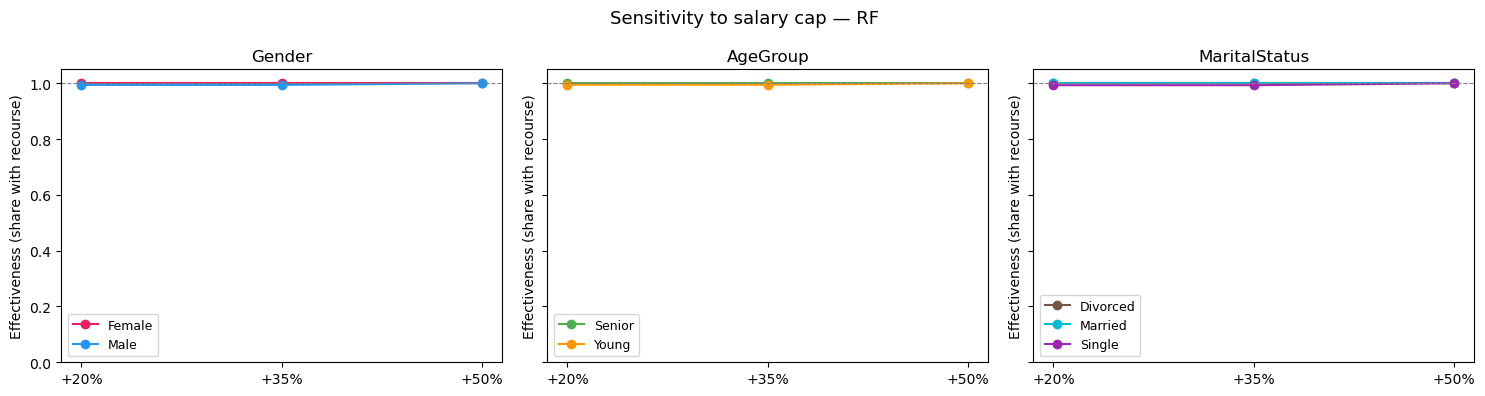

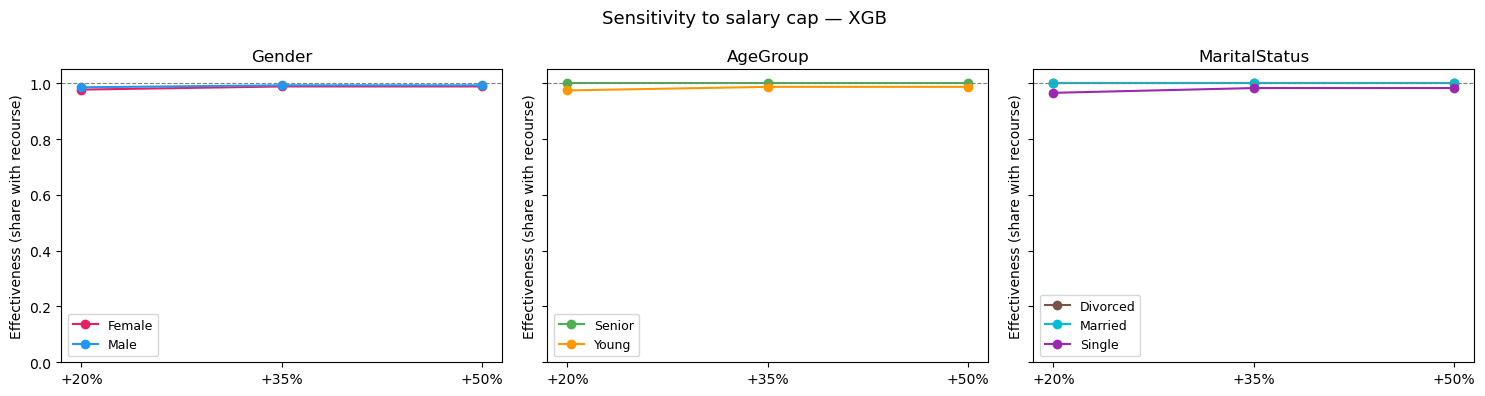

In [ ]:
cap_order  = ['tight', 'moderate', 'loose']
cap_labels = ['+20%', '+35%', '+50%']
colors     = {'Female': '#E91E63', 'Male': '#2196F3',
              'Young': '#FF9800', 'Senior': '#4CAF50',
              'Single': '#9C27B0', 'Married': '#00BCD4', 'Divorced': '#795548'}

for model_name in ['RF', 'XGB']:
    fig, axes = plt.subplots(1, len(PROTECTED_ATTRIBUTES),
                             figsize=(5 * len(PROTECTED_ATTRIBUTES), 4),
                             sharey=True)
    fig.suptitle(f'Sensitivity to salary cap — {model_name}', fontsize=13)

    for ax, attr in zip(axes, PROTECTED_ATTRIBUTES):
        sub_df = summary[(summary['model'] == model_name) &
                          (summary['attribute'] == attr)]
        for g in sorted(sub_df['group'].unique()):
            g_df = sub_df[sub_df['group'] == g]
            g_df = g_df.set_index('config').reindex(cap_order)
            ax.plot(cap_labels, g_df['effectiveness'].values,
                    marker='o', label=str(g),
                    color=colors.get(str(g), None))
        ax.set_title(attr)
        ax.set_ylabel('Effectiveness (share with recourse)')
        ax.set_ylim(0, 1.05)
        ax.axhline(1.0, color='gray', linestyle='--', linewidth=0.8)
        ax.legend(fontsize=9)

    plt.tight_layout()
    plt.savefig(os.path.join(PATHS['FAIRNESS'],
                f'sensitivity_{model_name}_effectiveness.png'), dpi=120)
    plt.show()


## 2.2. How to read these results

**If all lines drop together** (parallel): the salary constraint affects all
subgroups equally — the model is salary-fair, and the high effectiveness in
notebook 04 was not hiding a bias.

**If some lines drop faster than others**: those subgroups depend more on
salary changes to achieve recourse. This is a form of bias that Equal
Effectiveness (at 100%) in notebook 04 could not reveal — it only surfaces
when you tighten the budget.

**Connection to FACTS:** this analysis operationalises the
*Equal Effectiveness within Budget* notion (Kavouras et al., 2023) with the
salary cap as the budget parameter. The sensitivity plot is essentially the
effectiveness-cost distribution (ecd) of FACTS, sliced by subgroup and
parameterised by employer budget.

These results feed directly into notebook `06_FACTS.ipynb`, which computes
the full set of FACTS metrics including the gap statistics.
